In [ ]:
from sklearn import tree


def build_decision_tree(min_samples_leaf, min_samples_split, random_state):
    model = tree.DecisionTreeClassifier(
        criterion='gini',                    # split quality measure
        max_depth=None,                      # no depth limit
        min_samples_leaf=min_samples_leaf,   # regularization knob #1
        min_samples_split=min_samples_split, # regularization knob #2
        random_state=random_state            # reproducibility
    )

    return model

In [ ]:
seed = 4000
min_samples_leaf = 2
min_samples_split = 3

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

print(clf)
print(clf.get_params())

DecisionTreeClassifier(min_samples_leaf=2, min_samples_split=3,
                       random_state=4000)
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 3, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 4000, 'splitter': 'best'}


In [ ]:
def train_tree(clf, X, y):

    clf.fit(X, y)

    return None

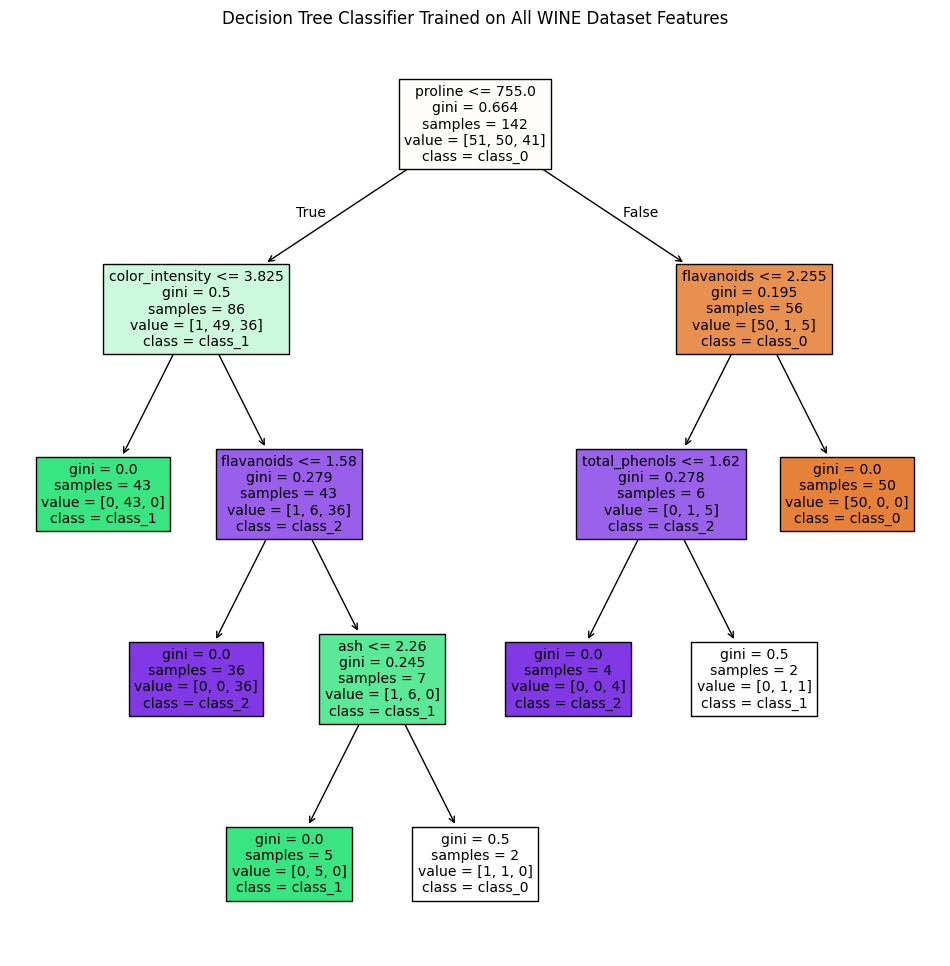

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf = 2
min_samples_split = 3
feature_names = wine.feature_names
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

train_tree(clf, X_train, y_train)

plt.figure(figsize=(12, 12))
plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree Classifier Trained on All WINE Dataset Features")
plt.savefig("trained_decision_tree.png")
plt.show()

In [ ]:
print(tree.export_text(clf))

|--- feature_12 <= 755.00
|   |--- feature_9 <= 3.82
|   |   |--- class: 1
|   |--- feature_9 >  3.82
|   |   |--- feature_6 <= 1.58
|   |   |   |--- class: 2
|   |   |--- feature_6 >  1.58
|   |   |   |--- feature_2 <= 2.26
|   |   |   |   |--- class: 1
|   |   |   |--- feature_2 >  2.26
|   |   |   |   |--- class: 0
|--- feature_12 >  755.00
|   |--- feature_6 <= 2.25
|   |   |--- feature_5 <= 1.62
|   |   |   |--- class: 2
|   |   |--- feature_5 >  1.62
|   |   |   |--- class: 1
|   |--- feature_6 >  2.25
|   |   |--- class: 0



In [ ]:

def draw(clf, feature_names, class_names):

    class_names = [str(name) for name in class_names]

    tree_rules = tree.export_text(
        clf,
        feature_names=list(feature_names),
        class_names=class_names
    )

    print(tree_rules)

    return None

In [ ]:

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf = 2
min_samples_split = 3
feature_names = wine.feature_names
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

train_tree(clf, X_train, y_train)

draw(clf, feature_names,class_names)


|--- proline <= 755.00
|   |--- color_intensity <= 3.82
|   |   |--- class: class_1
|   |--- color_intensity >  3.82
|   |   |--- flavanoids <= 1.58
|   |   |   |--- class: class_2
|   |   |--- flavanoids >  1.58
|   |   |   |--- ash <= 2.26
|   |   |   |   |--- class: class_1
|   |   |   |--- ash >  2.26
|   |   |   |   |--- class: class_0
|--- proline >  755.00
|   |--- flavanoids <= 2.25
|   |   |--- total_phenols <= 1.62
|   |   |   |--- class: class_2
|   |   |--- total_phenols >  1.62
|   |   |   |--- class: class_1
|   |--- flavanoids >  2.25
|   |   |--- class: class_0



In [ ]:

def generate_predictions(clf, X):

    predictions = clf.predict(X)

    return predictions

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf = 2
min_samples_split = 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

train_tree(clf, X_train, y_train)

predictions = generate_predictions(clf, X_test)
print("Prediction vs Ground Truth Labels:\n")
for pred, true in zip(predictions, y_test):
    print(f"Predicted: {pred}   |   Actual: {true}")

Prediction vs Ground Truth Labels:

Predicted: 1   |   Actual: 1
Predicted: 2   |   Actual: 1
Predicted: 0   |   Actual: 0
Predicted: 2   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 1   |   Actual: 1
Predicted: 0   |   Actual: 1
Predicted: 1   |   Actual: 1
Predicted: 1   |   Actual: 0
Predicted: 0   |   Actual: 1
Predicted: 2   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 2   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 2   |   Actual: 1
Predicted: 2   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 0   |   Actual: 0
Predicted: 0   |   Actual: 0
Predicted: 0   |   Actual: 0
Predicted: 2   |   Actual: 2
Predicted: 0   |   Actual: 1
Predicted: 0   |   Actual: 1
Predicted: 2   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 0   |   Actual: 0
Predicted: 0   |   Actual: 0
Predicted: 1   |   Actual: 1
Predicted: 0   |   Actual: 0
Predicted: 0   |   Actual: 1
Predicted: 1   |   Actual: 2
Predicted: 1   |   Actual: 1
Predicted: 1   |   Actual: 1
Predict

In [ ]:

from sklearn import metrics


def evaluate(true_labels, predicted_labels, class_names):

    report = metrics.classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )

    return report

In [ ]:

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf = 2
min_samples_split = 3
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

train_tree(clf, X_train, y_train)

y_pred = generate_predictions(clf, X_test)

classification_report = evaluate(y_test, y_pred, class_names)
print("\n         Decision Tree Classifier - Classification Report\n")
print(classification_report)



         Decision Tree Classifier - Classification Report

              precision    recall  f1-score   support

     class_0       0.58      0.88      0.70         8
     class_1       0.88      0.67      0.76        21
     class_2       0.75      0.86      0.80         7

    accuracy                           0.75        36
   macro avg       0.74      0.80      0.75        36
weighted avg       0.79      0.75      0.75        36



In [ ]:

from sklearn import model_selection


def prepruning(X, y, clf):

    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': list(range(2, 5)),
        'min_samples_leaf': list(range(2, 5)),
        'min_samples_split': list(range(2, 5)),
    }

    grid_search = model_selection.GridSearchCV(
        estimator=clf,
        param_grid=param_grid
    )

    grid_search.fit(X, y)

    return grid_search.best_params_

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn import tree


wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf = 2
min_samples_split = 3
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

best_params = prepruning(X_train, y_train,clf)
print("Best parameters for prepruning:", best_params)

prepuned_clf = tree.DecisionTreeClassifier(**best_params, random_state=seed)
train_tree(prepuned_clf, X_train, y_train)

y_pred = generate_predictions(prepuned_clf, X_test)
classification_report = evaluate(y_test, y_pred, class_names)
print("\n         Decision Tree Classifier After Pre-Pruning - Classification Report\n")
print(classification_report)

Best parameters for prepruning: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}

         Decision Tree Classifier After Pre-Pruning - Classification Report

              precision    recall  f1-score   support

     class_0       0.75      0.75      0.75         8
     class_1       0.94      0.81      0.87        21
     class_2       0.70      1.00      0.82         7

    accuracy                           0.83        36
   macro avg       0.80      0.85      0.82        36
weighted avg       0.85      0.83      0.84        36



In [ ]:

def get_pruning_path(clf, X, y):

    path = clf.cost_complexity_pruning_path(X, y)

    ccp_alphas = path.ccp_alphas
    impurities = path.impurities

    return ccp_alphas, impurities

CCP alpha values: [0.         0.00469484 0.00503018 0.06497317 0.07243461 0.21830986
 0.28413084]
Total impurities: [0.01408451 0.01877934 0.02380952 0.0887827  0.1612173  0.37952716
 0.663658  ]


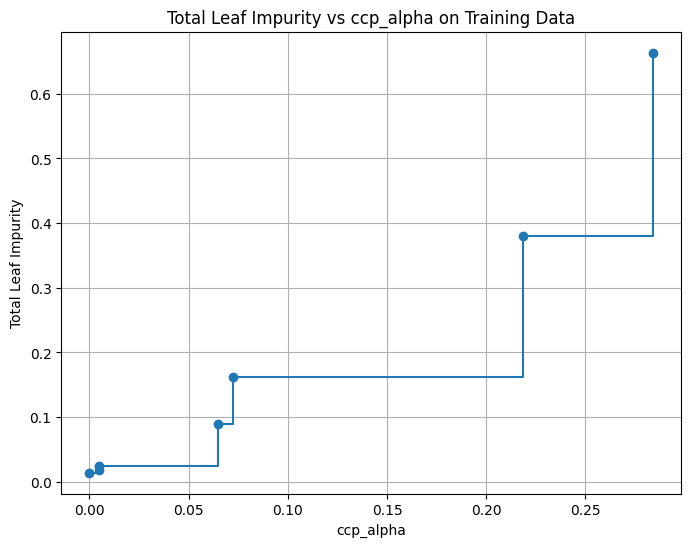

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf =2
min_samples_split=3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

ccp_alphas, impurities = get_pruning_path(clf, X_train, y_train)
print("CCP alpha values:", ccp_alphas)
print("Total impurities:", impurities)

plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle='steps-post')
plt.xlabel("ccp_alpha")
plt.ylabel("Total Leaf Impurity")
plt.title("Total Leaf Impurity vs ccp_alpha on Training Data")
plt.grid(True)
plt.show()

In [ ]:

from sklearn import tree


def prune_and_evaluate_trees(X_train, y_train, X_test, y_test, ccp_alphas,
                              random_state, min_samples_leaf,
                              min_samples_split):

    clfs = []
    train_scores = []
    test_scores = []

    for ccp_alpha in ccp_alphas:
        clf = tree.DecisionTreeClassifier(
            random_state=random_state,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            ccp_alpha=ccp_alpha
        )

        train_tree(clf, X_train, y_train)

        train_scores.append(clf.score(X_train, y_train))
        test_scores.append(clf.score(X_test, y_test))
        clfs.append(clf)

    return clfs, train_scores, test_scores

Training Scores: [0.9859154929577465, 0.9859154929577465, 0.9859154929577465, 0.9507042253521126, 0.9084507042253521, 0.6971830985915493, 0.3591549295774648]
Testing Scores: [0.75, 0.7777777777777778, 0.8333333333333334, 0.8333333333333334, 0.7222222222222222, 0.6944444444444444, 0.2222222222222222]


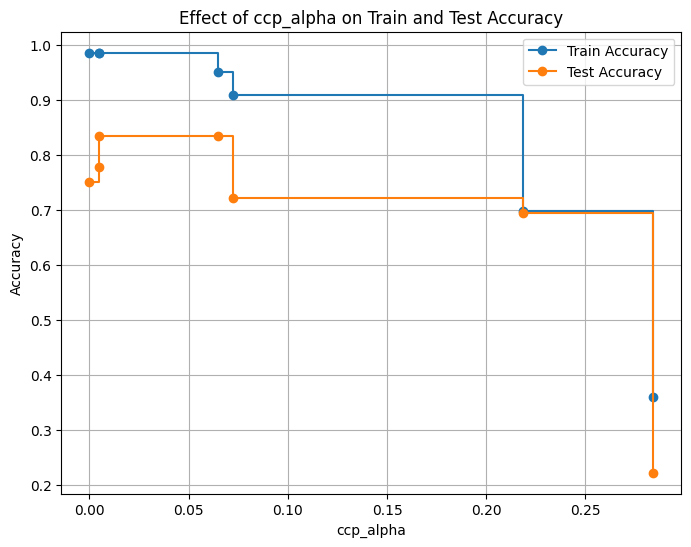

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf =2
min_samples_split=3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

ccp_alphas, _ = get_pruning_path(clf, X_train, y_train)

clfs, train_scores, test_scores = prune_and_evaluate_trees(
    X_train, y_train, X_test, y_test, ccp_alphas, seed,
    min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split)

print("Training Scores:", train_scores)
print("Testing Scores:", test_scores)

plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy', drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy', drawstyle='steps-post')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Effect of ccp_alpha on Train and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


def get_best_alpha(clfs, train_scores, test_scores, ccp_alphas):

    n = len(clfs)

    # Sort key per candidate, in priority order:
    #   1. test_score            -> higher is better
    #   2. -|train - test| gap   -> smaller gap is better, so negate
    #                               it to keep "higher is better"
    #   3. ccp_alpha              -> higher is better (simpler tree)
    def sort_key(i):
        gap = abs(train_scores[i] - test_scores[i])
        return (test_scores[i], -gap, ccp_alphas[i])

    best_index = max(range(n), key=sort_key)

    best_alpha = ccp_alphas[best_index]
    best_clf = clfs[best_index]

    return best_alpha, best_clf

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
min_samples_leaf =2
min_samples_split=3
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

clf = build_decision_tree(min_samples_leaf=min_samples_leaf,
                          min_samples_split=min_samples_split,
                          random_state=seed)

ccp_alphas, _ = get_pruning_path(clf, X_train, y_train)

clfs, train_scores, test_scores = prune_and_evaluate_trees(
    X_train, y_train, X_test, y_test, ccp_alphas, seed,
    min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split)

best_alpha, best_pruned_clf = get_best_alpha(clfs, train_scores, test_scores, ccp_alphas)
print(f"Best alpha: {best_alpha}")

y_pred = generate_predictions(best_pruned_clf, X_test)
classification_report = evaluate(y_test, y_pred, class_names)
print("\n         Post Pruned Decision Tree Classifier - Classification Report\n")
print(classification_report)

Best alpha: 0.06497317236753855

         Post Pruned Decision Tree Classifier - Classification Report

              precision    recall  f1-score   support

     class_0       0.64      0.88      0.74         8
     class_1       0.94      0.81      0.87        21
     class_2       0.86      0.86      0.86         7

    accuracy                           0.83        36
   macro avg       0.81      0.85      0.82        36
weighted avg       0.86      0.83      0.84        36



In [ ]:

from sklearn import ensemble


def random_forest(n_estimators, random_state):

    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state
    )

    return model

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
n = 20
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

rf = random_forest(n_estimators=n, random_state=seed)
print(rf)
print(rf.get_params())

train_tree(rf, X_train, y_train)

y_pred = generate_predictions(rf, X_test)

classification_report = evaluate(y_test, y_pred, class_names)
print("\n         Random Forest Classifier - Classification Report\n")
print(classification_report)

RandomForestClassifier(n_estimators=20, random_state=4000)
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 20, 'n_jobs': None, 'oob_score': False, 'random_state': 4000, 'verbose': 0, 'warm_start': False}

         Random Forest Classifier - Classification Report

              precision    recall  f1-score   support

     class_0       0.89      1.00      0.94         8
     class_1       1.00      0.90      0.95        21
     class_2       0.88      1.00      0.93         7

    accuracy                           0.94        36
   macro avg       0.92      0.97      0.94        36
weighted avg       0.95      0.94      0.94        36



In [ ]:

import numpy as np


def feature_importance(rf):

    importances = rf.feature_importances_
    indices = np.argsort(importances)

    return importances, indices

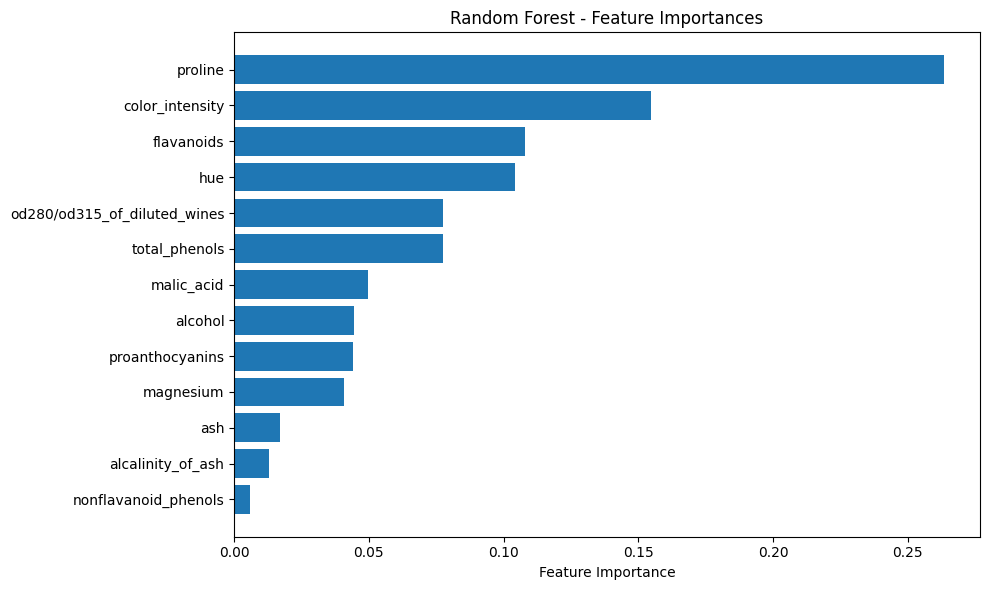

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
n = 20
feature_names = wine.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

rf = random_forest(n_estimators=n, random_state=seed)

train_tree(rf, X_train, y_train)

importances, indices = feature_importance(rf)

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:

from sklearn import ensemble
import xgboost as xgb
import lightgbm as lgb


def compare_boosting_classifiers(name, n_estimators, random_state):

    if name == "adaboost":
        model = ensemble.AdaBoostClassifier(
            n_estimators=n_estimators,
            random_state=random_state
        )
    elif name == "gradientboosting":
        model = ensemble.GradientBoostingClassifier(
            n_estimators=n_estimators,
            random_state=random_state
        )
    elif name == "xgboost":
        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            random_state=random_state
        )
    elif name == "lightgbm":
        model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            random_state=random_state,
            verbose=-1
        )
    else:
        raise ValueError(f"Unknown model name '{name}'")

    return model

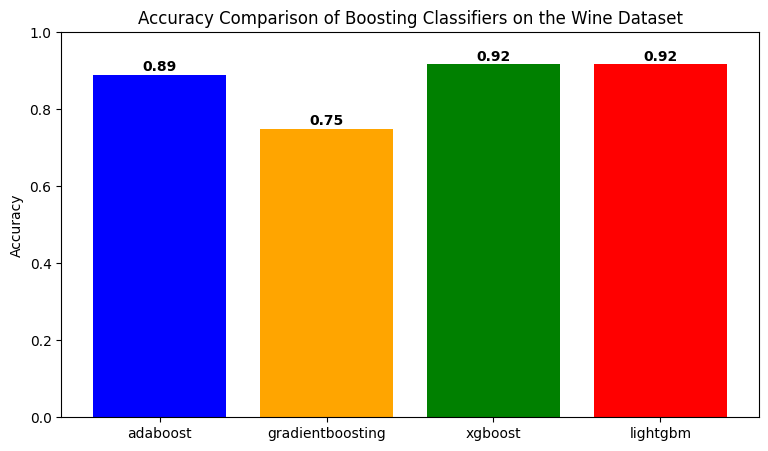

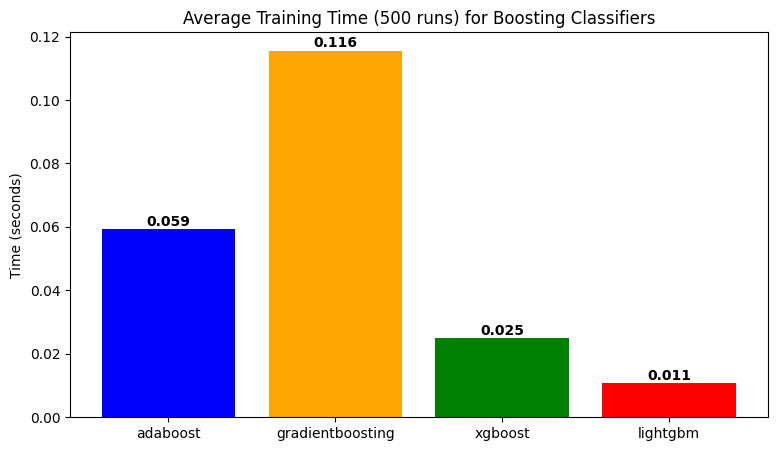

In [ ]:
#!/usr/bin/env python3

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import time
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings

wine = load_wine()
X = wine.data
y = wine.target

seed = 4000
n_estimators = 20
n_runs = 500

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

model_names = ["adaboost", "gradientboosting", "xgboost", "lightgbm"]

accuracies = {}
avg_train_times = {}

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

for name in model_names:

    times = []
    for _ in range(n_runs):
        model = compare_boosting_classifiers(name, n_estimators, seed)
        start = time.time()
        train_tree(model, X_train, y_train)
        end = time.time()
        times.append(end - start)
    avg_time = sum(times) / n_runs

    train_tree(model, X_train, y_train)
    y_pred = generate_predictions(model, X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies[name] = acc
    avg_train_times[name] = avg_time

plt.figure(figsize=(9, 5))
colors = ['blue', 'orange', 'green', 'red']
plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.title("Accuracy Comparison of Boosting Classifiers on the Wine Dataset")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(avg_train_times.keys(), avg_train_times.values(), color=colors)
plt.ylabel("Time (seconds)")
plt.title("Average Training Time (500 runs) for Boosting Classifiers")
for i, v in enumerate(avg_train_times.values()):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()